##Download content from wikipedia
First wikipedia library must be installed

In [ ]:
!pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11679 sha256=6f072c24e66d7c5eede5da2c44c710646b58dab1b2fc4ccadfaebcd9fffc31d8
  Stored in directory: /root/.cache/pip/wheels/5e/b6/c5/93f3dec388ae76edc830cb42901bb0232504dfc0df02fc50de
Successfully built wikipedia


Download content from Wikipedia on
* Data Science
* Artificial intelligence
* Machine Learning
* European Central Bank
* Bank
* Financial technology
* International Monetary Fund
* Basketball
* Swimming
* Tennis

In [ ]:
import pandas as pd
import wikipedia
articles=['Data Science','Artificial intelligence',
          'European Central Bank','Bank','Financial technology','International Monetary Fund',
          'Basketball','Swimming']
wiki_lst=[]
title=[]
for article in articles:
    print("loading content: ",article)
    wiki_lst.append(wikipedia.page(article).content)
    title.append(article)
print("examine content")
wiki_lst

loading content:  Data Science
loading content:  Artificial intelligence
loading content:  European Central Bank
loading content:  Bank
loading content:  Financial technology
loading content:  International Monetary Fund
loading content:  Basketball
loading content:  Swimming
examine content


['Data science is an interdisciplinary academic field that uses statistics, scientific computing, scientific methods, processes, algorithms and systems to extract or extrapolate knowledge and insights from noisy, structured, and unstructured data.Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession.Data science is a "concept to unify statistics, data analysis, informatics, and their related methods" to "understand and analyze actual phenomena" with data. It uses techniques and theories drawn from many fields within the context of mathematics, statistics, computer science, information science, and domain knowledge. However, data science is different from computer science and information science. Turing Award winner Jim Gray imagined data science as

##TF-IDF example

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(wiki_lst)

In [ ]:
print(vectorizer.get_feature_names())
print(X.shape)

['00', '000', '0001', '001', '008', '01', '03', '048', '05', '06', '07', '08', '10', '100', '1000', '100k', '101', '11', '110', '115', '12', '120', '12000', '122', '123', '127', '128', '129', '12th', '13', '13000', '1316', '1397', '13th', '14', '140', '1407', '141', '14th', '15', '150', '1500', '1538', '155', '1599', '16', '160', '169', '1695', '16th', '17', '1700', '1728', '17th', '18', '180', '1800', '18000', '1830', '1859', '1861', '1863', '1865', '1872', '1873', '1874', '1875', '1877', '188', '1880', '1881', '1887', '189', '1890s', '1891', '1892', '1893', '1895', '1896', '1897', '1898', '1899', '18th', '19', '1900', '1901', '1904', '1905', '1906', '1907', '1908', '1910', '1913', '1915', '1917', '1920', '1920s', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1930s', '1932', '1936', '1937', '1938', '1939', '1940', '1940s', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1950s', '1951', '1952', '1953', '1954', '1956', '1959', '1960', 

In [ ]:
print(X[0,])

  (0, 5052)	0.005856723383009103
  (0, 3556)	0.014728118248505815
  (0, 4893)	0.010995865271559848
  (0, 6696)	0.0073640591242529075
  (0, 4271)	0.006556372961328721
  (0, 3009)	0.006556372961328721
  (0, 4651)	0.006556372961328721
  (0, 3646)	0.01312033567762298
  (0, 5322)	0.010995865271559848
  (0, 6561)	0.010995865271559848
  (0, 4567)	0.0073640591242529075
  (0, 3797)	0.005856723383009103
  (0, 1751)	0.006556372961328721
  (0, 2085)	0.009488529530316042
  (0, 606)	0.008319349096313308
  (0, 1405)	0.010995865271559848
  (0, 1025)	0.0073640591242529075
  (0, 3322)	0.01312033567762298
  (0, 5970)	0.010995865271559848
  (0, 3997)	0.010995865271559848
  (0, 341)	0.010995865271559848
  (0, 4192)	0.01312033567762298
  (0, 6394)	0.010995865271559848
  (0, 6192)	0.009488529530316042
  (0, 1641)	0.008319349096313308
  :	:
  (0, 4088)	0.006556372961328721
  (0, 593)	0.04398346108623939
  (0, 6387)	0.010995865271559848
  (0, 2043)	0.054979326357799244
  (0, 3308)	0.01312033567762298
  (0, 644

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

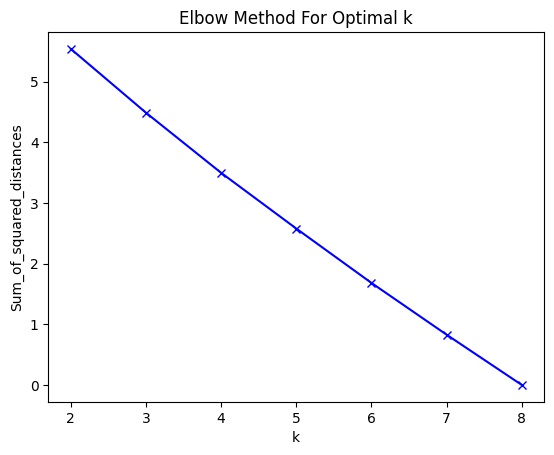

In [ ]:
Sum_of_squared_distances = []
K = range(2,10)
for k in K:
    km = KMeans(n_clusters=k, max_iter=200, n_init=10, random_state=42)
    if X.shape[0] >= k:
        km = km.fit(X)
        Sum_of_squared_distances.append(km.inertia_)
    else:
        # Handle the case where the number of clusters is greater than the number of samples
        Sum_of_squared_distances.append(float('inf'))

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
true_k = 6
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=200, n_init=10)
model.fit(X)
labels=model.labels_
wiki_cl=pd.DataFrame(list(zip(title,labels)),columns=['title','cluster'])
print(wiki_cl.sort_values(by=['cluster']))

                         title  cluster
2        European Central Bank        0
5  International Monetary Fund        0
0                 Data Science        1
6                   Basketball        2
1      Artificial intelligence        3
4         Financial technology        3
3                         Bank        4
7                     Swimming        5


Cluster: 0
Titles
      European Central Bank
International Monetary Fund


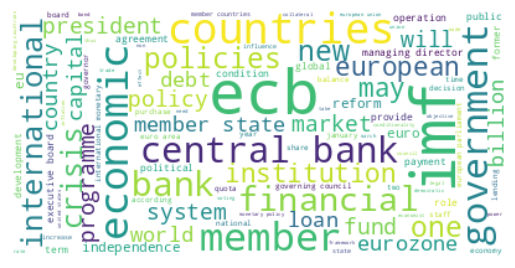

Cluster: 1
Titles
Data Science


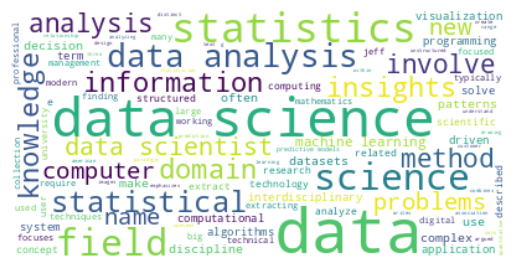

Cluster: 2
Titles
Basketball


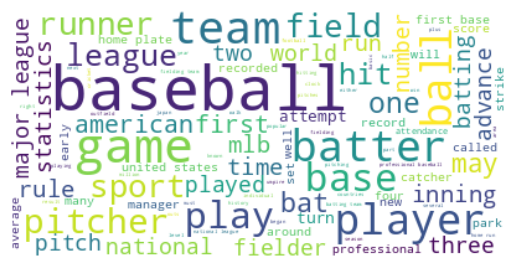

Cluster: 3
Titles
Artificial intelligence
   Financial technology


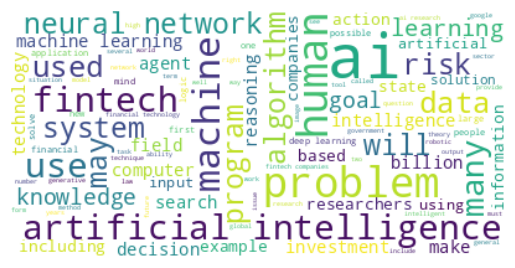

Cluster: 4
Titles
Bank


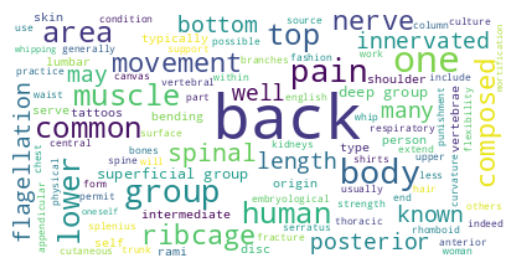

Cluster: 5
Titles
Swimming


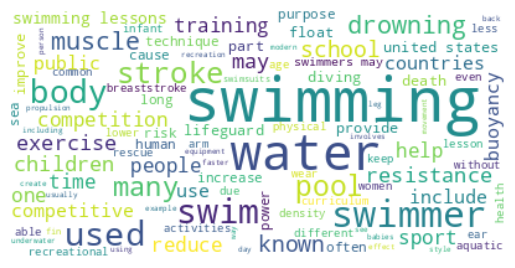

In [ ]:
from wordcloud import WordCloud
result={'cluster':labels,'wiki':wiki_lst}
result=pd.DataFrame(result)
for k in range(0,true_k):
    s=result[result.cluster==k]
    text=s['wiki'].str.cat(sep=' ')
    text=text.lower()
    text=' '.join([word for word in text.split()])
    wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
    print('Cluster: {}'.format(k))
    print('Titles')
    titles=wiki_cl[wiki_cl.cluster==k]['title']
    print(titles.to_string(index=False))
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()